# Week 4 Task: Predictive Modeling and Optimization in Logistics Systems

## Project: Delivery Time Prediction and Logistics Optimization

### Objective
To develop predictive machine learning models for forecasting logistics delivery time and use the model insights to propose practical optimization strategies for improving logistics operations.


In [1]:
# Section 2: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 3: Logistics Dataset Simulation

We simulate a logistics dataset containing shipment, transportation, warehouse, and environmental factors. The target variable is Delivery_Time_Days, which represents the number of days required to deliver a shipment.

In [2]:
# Section 3: Simulate Logistics Dataset

np.random.seed(42)

n = 1500

data = pd.DataFrame({
    "Distance_km": np.random.randint(50, 2500, n),
    "Weight_kg": np.random.uniform(1, 1000, n).round(2),
    "Traffic_Level": np.random.choice(
        ["Low", "Medium", "High"], n, p=[0.30, 0.45, 0.25]
    ),
    "Weather": np.random.choice(
        ["Clear", "Cloudy", "Rainy", "Stormy"],
        n,
        p=[0.45, 0.25, 0.20, 0.10]
    ),
    "Carrier": np.random.choice(
        ["Carrier A", "Carrier B", "Carrier C"], n
    ),
    "Vehicle_Type": np.random.choice(
        ["Van", "Truck", "Heavy Truck"], n
    ),
    "Warehouse_Processing_Hours": np.random.uniform(1, 24, n).round(2),
    "Priority": np.random.choice(
        ["Standard", "Express", "Urgent"],
        n,
        p=[0.60, 0.30, 0.10]
    )
})

# Numerical effects used to create a realistic target variable
traffic_effect = data["Traffic_Level"].map({
    "Low": 0.0,
    "Medium": 0.8,
    "High": 1.8
})

weather_effect = data["Weather"].map({
    "Clear": 0.0,
    "Cloudy": 0.2,
    "Rainy": 0.7,
    "Stormy": 1.5
})

carrier_effect = data["Carrier"].map({
    "Carrier A": 0.0,
    "Carrier B": 0.6,
    "Carrier C": 0.3
})

vehicle_effect = data["Vehicle_Type"].map({
    "Van": 0.5,
    "Truck": 0.2,
    "Heavy Truck": 0.0
})

priority_effect = data["Priority"].map({
    "Standard": 0.8,
    "Express": 0.0,
    "Urgent": -0.5
})

# Create target variable: Delivery Time
data["Delivery_Time_Days"] = (
    1.5
    + (data["Distance_km"] / 500)
    + (data["Weight_kg"] / 1500)
    + (data["Warehouse_Processing_Hours"] / 12)
    + traffic_effect
    + weather_effect
    + carrier_effect
    + vehicle_effect
    + priority_effect
    + np.random.normal(0, 0.7, n)
)

# Prevent unrealistic negative delivery times
data["Delivery_Time_Days"] = data["Delivery_Time_Days"].clip(lower=0.5).round(2)

print("Dataset created successfully!")
print("Shape:", data.shape)

display(data.head())

Dataset created successfully!
Shape: (1500, 9)


,Distance_km,Weight_kg,Traffic_Level,Weather,Carrier,Vehicle_Type,Warehouse_Processing_Hours,Priority,Delivery_Time_Days
0,910,722.17,High,Clear,Carrier B,Truck,14.79,Urgent,7.83
1,1344,657.33,High,Rainy,Carrier A,Heavy Truck,4.94,Standard,8.49
2,1180,757.30,Medium,Clear,Carrier A,Van,18.06,Standard,7.87
3,1145,952.70,High,Clear,Carrier A,Van,7.96,Standard,8.95
4,1688,907.91,High,Clear,Carrier B,Van,16.23,Standard,10.50


## Section 4: Data Inspection and Quality Checks

Before building the predictive models, the dataset is inspected for its structure, missing values, duplicate records, and basic statistical properties. These checks help ensure that the simulated data is suitable for model development.

In [3]:
# Check dataset information

print("Dataset Information:")
print("--------------------")
data.info()

print("\nMissing Values:")
print("--------------------")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print("--------------------")
print(data.duplicated().sum())

print("\nStatistical Summary:")
print("--------------------")
display(data.describe())

Dataset Information:
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Distance_km                 1500 non-null   int64  
 1   Weight_kg                   1500 non-null   float64
 2   Traffic_Level               1500 non-null   object 
 3   Weather                     1500 non-null   object 
 4   Carrier                     1500 non-null   object 
 5   Vehicle_Type                1500 non-null   object 
 6   Warehouse_Processing_Hours  1500 non-null   float64
 7   Priority                    1500 non-null   object 
 8   Delivery_Time_Days          1500 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 105.6+ KB

Missing Values:
--------------------
Distance_km                   0
Weight_kg                     0
Traffic_Level                 0
Weather                    

,Distance_km,Weight_kg,Warehouse_Processing_Hours,Delivery_Time_Days
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,1267.130667,500.220133,12.209453,7.533353
std,696.363732,285.718984,6.510745,1.952101
min,51.000000,1.190000,1.000000,1.660000
25%,694.000000,246.390000,6.772500,6.140000
50%,1263.000000,514.810000,11.965000,7.540000
75%,1871.500000,742.130000,17.572500,8.860000
max,2499.000000,999.710000,23.930000,13.240000


## Section 5: Exploratory Data Analysis

Exploratory data analysis is performed to understand the relationships between logistics factors and delivery time. The analysis focuses on distance, traffic conditions, weather conditions, and carrier performance because these variables can directly influence transportation efficiency and delivery duration.

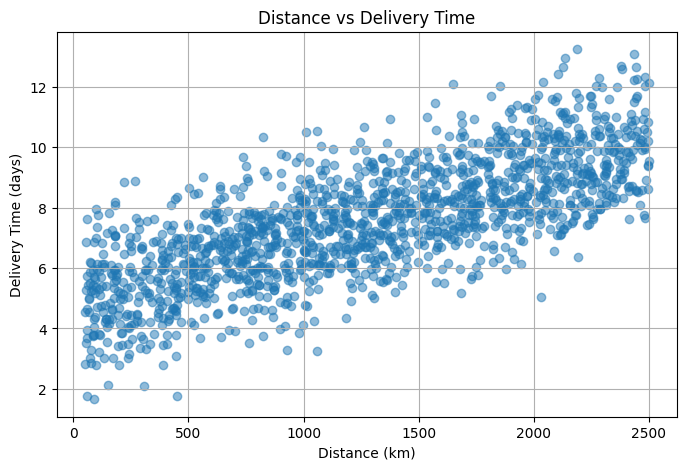

Correlation between distance and delivery time: 0.744


In [4]:
# Section 5.1: Distance vs Delivery Time

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Distance_km"],
    data["Delivery_Time_Days"],
    alpha=0.5
)

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (days)")
plt.title("Distance vs Delivery Time")
plt.grid(True)
plt.show()

# Calculate correlation
distance_corr = data["Distance_km"].corr(data["Delivery_Time_Days"])

print(f"Correlation between distance and delivery time: {distance_corr:.3f}")

### 5.2 Traffic Level and Delivery Time

Traffic conditions are analyzed to determine whether different traffic levels are associated with differences in average delivery time.

Traffic Level Analysis:


,Average_Delivery_Time,Shipment_Count
Traffic_Level,,
Low,6.70,429
Medium,7.52,677
High,8.47,394


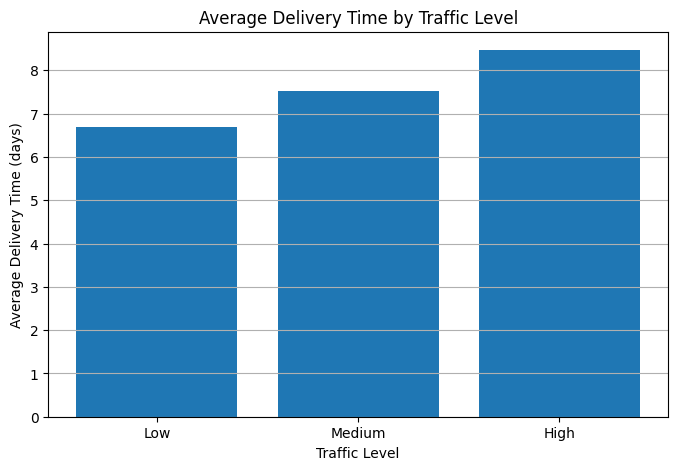

In [5]:
# Calculate average delivery time by traffic level

traffic_summary = (
    data.groupby("Traffic_Level")["Delivery_Time_Days"]
    .agg(["mean", "count"])
    .reindex(["Low", "Medium", "High"])
)

traffic_summary.columns = ["Average_Delivery_Time", "Shipment_Count"]

print("Traffic Level Analysis:")
display(traffic_summary.round(2))

# Visualization
plt.figure(figsize=(8, 5))

plt.bar(
    traffic_summary.index,
    traffic_summary["Average_Delivery_Time"]
)

plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (days)")
plt.title("Average Delivery Time by Traffic Level")
plt.grid(axis="y")
plt.show()

### 5.3 Weather Conditions and Delivery Time

Weather conditions are analyzed to determine whether adverse weather is associated with longer delivery times. This analysis helps identify weather-related risks that can be considered in logistics planning and delivery-time prediction.

Weather Condition Analysis:


,Average_Delivery_Time,Shipment_Count
Weather,,
Clear,7.22,699
Cloudy,7.35,368
Rainy,7.91,307
Stormy,8.88,126


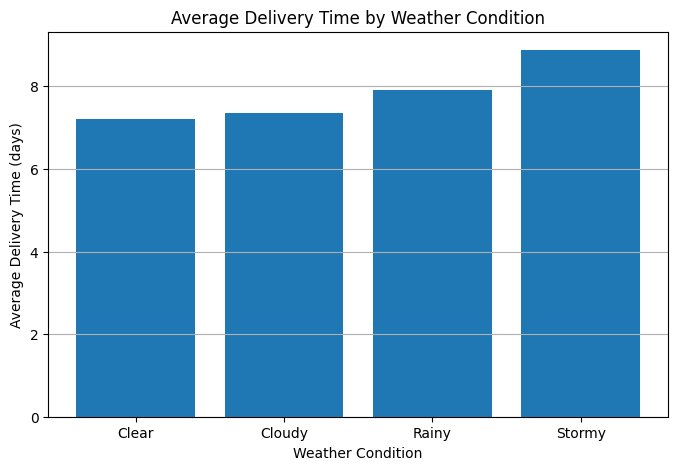

In [6]:
weather_summary = (
    data.groupby("Weather")["Delivery_Time_Days"]
    .agg(["mean", "count"])
    .reindex(["Clear", "Cloudy", "Rainy", "Stormy"])
)

weather_summary.columns = ["Average_Delivery_Time", "Shipment_Count"]

print("Weather Condition Analysis:")
display(weather_summary.round(2))

plt.figure(figsize=(8, 5))

plt.bar(
    weather_summary.index,
    weather_summary["Average_Delivery_Time"]
)

plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (days)")
plt.title("Average Delivery Time by Weather Condition")
plt.grid(axis="y")
plt.show()

### 5.4 Carrier Performance and Delivery Time

Carrier performance is analyzed by comparing the average delivery time across carriers. This helps identify differences in delivery performance and provides useful information for carrier selection and logistics optimization.

Carrier Performance Analysis:


,Average_Delivery_Time,Shipment_Count
Carrier,,
Carrier A,7.31,488
Carrier C,7.38,492
Carrier B,7.89,520


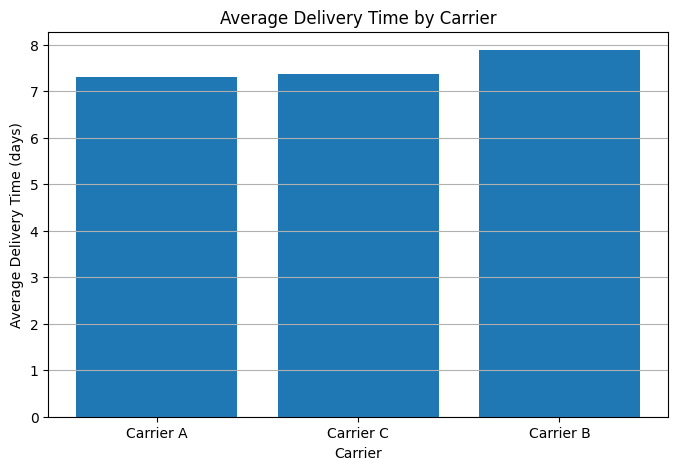

In [7]:
carrier_summary = (
    data.groupby("Carrier")["Delivery_Time_Days"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

carrier_summary.columns = ["Average_Delivery_Time", "Shipment_Count"]

print("Carrier Performance Analysis:")
display(carrier_summary.round(2))

plt.figure(figsize=(8, 5))

plt.bar(
    carrier_summary.index,
    carrier_summary["Average_Delivery_Time"]
)

plt.xlabel("Carrier")
plt.ylabel("Average Delivery Time (days)")
plt.title("Average Delivery Time by Carrier")
plt.grid(axis="y")
plt.show()

In [ ]:
### 5.5 EDA Summary

The exploratory analysis identified several logistics factors associated with delivery time. Distance showed a strong positive relationship with delivery time, while higher traffic levels, adverse weather conditions, and differences between carriers were associated with changes in average delivery duration. These findings provide the basis for selecting predictive features for the machine learning models.

In [8]:
print("Key EDA Findings")
print("-----------------")

print(f"Distance correlation with delivery time: {distance_corr:.3f}")

low_traffic = traffic_summary.loc["Low", "Average_Delivery_Time"]
high_traffic = traffic_summary.loc["High", "Average_Delivery_Time"]

print(f"Low traffic average delivery time: {low_traffic:.2f} days")
print(f"High traffic average delivery time: {high_traffic:.2f} days")
print(f"Traffic difference: {high_traffic - low_traffic:.2f} days")

clear_weather = weather_summary.loc["Clear", "Average_Delivery_Time"]
stormy_weather = weather_summary.loc["Stormy", "Average_Delivery_Time"]

print(f"Clear weather average delivery time: {clear_weather:.2f} days")
print(f"Stormy weather average delivery time: {stormy_weather:.2f} days")
print(f"Weather difference: {stormy_weather - clear_weather:.2f} days")

fastest_carrier = carrier_summary["Average_Delivery_Time"].idxmin()
slowest_carrier = carrier_summary["Average_Delivery_Time"].idxmax()

fastest_time = carrier_summary["Average_Delivery_Time"].min()
slowest_time = carrier_summary["Average_Delivery_Time"].max()

print(f"Lowest observed carrier average: {fastest_carrier} ({fastest_time:.2f} days)")
print(f"Highest observed carrier average: {slowest_carrier} ({slowest_time:.2f} days)")
print(f"Carrier difference: {slowest_time - fastest_time:.2f} days")

Key EDA Findings
-----------------
Distance correlation with delivery time: 0.744
Low traffic average delivery time: 6.70 days
High traffic average delivery time: 8.47 days
Traffic difference: 1.77 days
Clear weather average delivery time: 7.22 days
Stormy weather average delivery time: 8.88 days
Weather difference: 1.66 days
Lowest observed carrier average: Carrier A (7.31 days)
Highest observed carrier average: Carrier B (7.89 days)
Carrier difference: 0.58 days


### 6.1 Feature and Target Definition

The target variable for the predictive modeling task is Delivery_Time_Days. The remaining logistics attributes are used as input features. Numerical variables are retained as continuous features, while categorical variables such as traffic level, weather, carrier, vehicle type, and priority are encoded before model training.

In [9]:
# Define features and target

X = data.drop("Delivery_Time_Days", axis=1)
y = data["Delivery_Time_Days"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Delivery_Time_Days")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Distance_km', 'Weight_kg', 'Traffic_Level', 'Weather', 'Carrier', 'Vehicle_Type', 'Warehouse_Processing_Hours', 'Priority']

Target:
Delivery_Time_Days

Feature shape: (1500, 8)
Target shape: (1500,)


### 6.2 Numerical and Categorical Features

The input features are divided into numerical and categorical variables. Numerical features can be used directly by the regression models, while categorical features must be converted into numerical representations. One-hot encoding will be used for the categorical variables to avoid assigning artificial numerical relationships between categories.

In [10]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical Features:
['Distance_km', 'Weight_kg', 'Warehouse_Processing_Hours']

Categorical Features:
['Traffic_Level', 'Weather', 'Carrier', 'Vehicle_Type', 'Priority']

Number of numerical features: 3
Number of categorical features: 5


### 6.3 Train-Test Split

The dataset is divided into training and testing subsets to evaluate how well the models perform on unseen data. An 80:20 split is used, with 80% of the observations for model training and 20% reserved for final evaluation. A fixed random state is used to ensure reproducibility.

In [11]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (1200, 8)
y_train: (1200,)

Testing set:
X_test: (300, 8)
y_test: (300,)


### 6.4 Preprocessing Pipeline

The categorical variables are converted into numerical features using one-hot encoding. A ColumnTransformer is used to apply the transformation only to categorical variables while passing the numerical variables through unchanged. This preprocessing is integrated into a pipeline to prevent data leakage and ensure that the same transformations are applied consistently during model training and testing.

In [12]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Preprocessing pipeline created successfully!")
print("Categorical features will be one-hot encoded.")
print("Numerical features will be passed through unchanged.")

Preprocessing pipeline created successfully!
Categorical features will be one-hot encoded.
Numerical features will be passed through unchanged.


### 7.1 Linear Regression — Baseline Model

Linear Regression is used as the baseline model because it provides a simple and interpretable approach for predicting delivery time. The model estimates the relationship between the logistics input features and the target variable, Delivery_Time_Days. Its performance will be compared with more complex tree-based models.

In [13]:
# Linear Regression baseline model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {linear_mae:.3f}")
print(f"RMSE : {linear_rmse:.3f}")
print(f"R²   : {linear_r2:.3f}")

Linear Regression Results
-------------------------
MAE  : 0.541
RMSE : 0.675
R²   : 0.885


### 7.2 Decision Tree Regressor

A Decision Tree Regressor is tested to capture nonlinear relationships between logistics variables and delivery time. Unlike Linear Regression, a decision tree can model interactions and threshold-based patterns between numerical and categorical features.

In [14]:
# Decision Tree Regression model

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=10
        ))
    ]
)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Evaluate the model
tree_mae = mean_absolute_error(y_test, y_pred_tree)
tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
tree_r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("---------------------")
print(f"MAE  : {tree_mae:.3f}")
print(f"RMSE : {tree_rmse:.3f}")
print(f"R²   : {tree_r2:.3f}")

Decision Tree Results
---------------------
MAE  : 0.941
RMSE : 1.185
R²   : 0.645


### 7.3 Random Forest Regressor

Random Forest Regressor is tested as an ensemble learning model that combines multiple decision trees to improve predictive performance and reduce the instability of a single decision tree. The model is evaluated using MAE, RMSE, and R² on the unseen test dataset.

In [15]:
# Random Forest Regression model

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=12
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

Random Forest Results
---------------------
MAE  : 0.715
RMSE : 0.896
R²   : 0.797


### 7.4 Model Comparison

The three regression models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. Lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates that the model explains a larger proportion of the variation in delivery time.

Based on the test-set results, Linear Regression achieved the lowest MAE (0.541 days) and RMSE (0.675 days), along with the highest R² (0.885). Random Forest performed better than the Decision Tree but did not outperform Linear Regression. Therefore, Linear Regression is currently the strongest model on the held-out test set.

In [16]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

model_comparison = model_comparison.sort_values("MAE")

display(model_comparison.round(3))

,Model,MAE,RMSE,R2
0,Linear Regression,0.541,0.675,0.885
2,Random Forest,0.715,0.896,0.797
1,Decision Tree,0.941,1.185,0.645


### 8.1 Five-Fold Cross-Validation

Five-fold cross-validation is used to assess the stability and generalization of the predictive models. The dataset is divided into five parts, with each part used once as the validation set while the remaining four parts are used for training.

Mean Absolute Error (MAE) is used as the cross-validation scoring metric because it provides an interpretable measure of the average prediction error in days. The mean and standard deviation of the cross-validation scores are reported to understand both average performance and variation across folds.

In [17]:
# 5-Fold Cross-Validation

models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": random_forest_model
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    mae_scores = -scores

    cv_results.append({
        "Model": name,
        "Mean CV MAE": mae_scores.mean(),
        "Std CV MAE": mae_scores.std()
    })

cv_results = pd.DataFrame(cv_results)

display(cv_results.round(3))

,Model,Mean CV MAE,Std CV MAE
0,Linear Regression,0.553,0.025
1,Decision Tree,0.999,0.018
2,Random Forest,0.715,0.027


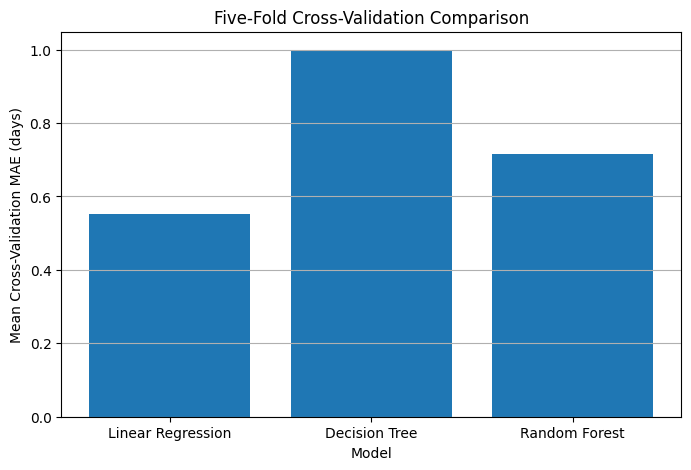

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results["Model"],
    cv_results["Mean CV MAE"]
)

plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation MAE (days)")
plt.title("Five-Fold Cross-Validation Comparison")
plt.grid(axis="y")
plt.show()

## 9. Hyperparameter Tuning

Hyperparameter tuning is performed to determine whether the Random Forest model can achieve improved predictive performance by adjusting its configuration. GridSearchCV is used to evaluate different combinations of hyperparameters using five-fold cross-validation.

The parameters considered include the number of trees, maximum tree depth, and minimum number of samples required to split an internal node. Mean Absolute Error is used as the optimization criterion because lower prediction error is preferred.

In [19]:
# Random Forest Hyperparameter Tuning

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(f"{-grid_search.best_score_:.3f} days")

Best Parameters:
{'model__max_depth': 12, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross-Validation MAE:
0.738 days


In [20]:
# Evaluate the tuned Random Forest on the test set

best_rf_model = grid_search.best_estimator_

y_pred_tuned_rf = best_rf_model.predict(X_test)

tuned_rf_mae = mean_absolute_error(y_test, y_pred_tuned_rf)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
tuned_rf_r2 = r2_score(y_test, y_pred_tuned_rf)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"MAE  : {tuned_rf_mae:.3f}")
print(f"RMSE : {tuned_rf_rmse:.3f}")
print(f"R²   : {tuned_rf_r2:.3f}")

Tuned Random Forest Results
---------------------------
MAE  : 0.715
RMSE : 0.896
R²   : 0.797


## 10. Actual vs Predicted Delivery Time

The predictions from the Linear Regression model are compared with the actual delivery times in the test dataset. A scatter plot is used to examine how closely the predicted values follow the actual values.

Predictions that are closer to the ideal diagonal relationship indicate better agreement between predicted and observed delivery times. The analysis provides a visual assessment of model performance in addition to numerical evaluation metrics.

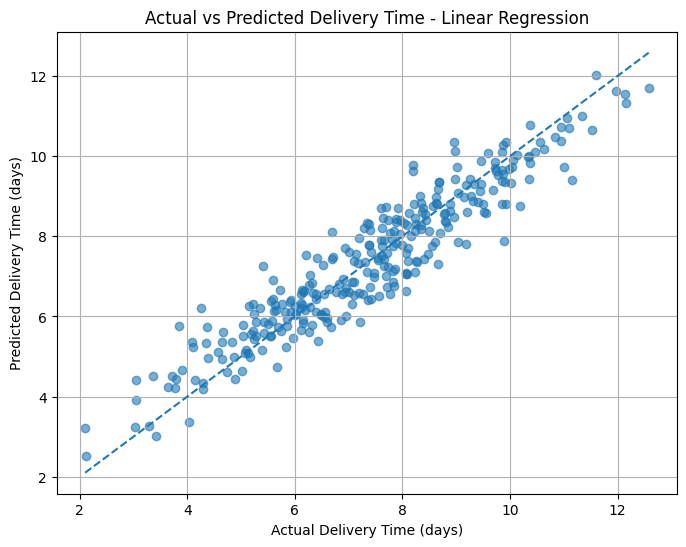

In [21]:
# Actual vs Predicted Delivery Time

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (days)")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("Actual vs Predicted Delivery Time - Linear Regression")
plt.grid(True)
plt.show()

In [22]:
# Prediction error analysis

prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_linear
})

prediction_results["Error"] = (
    prediction_results["Predicted"]
    - prediction_results["Actual"]
)

prediction_results["Absolute_Error"] = (
    prediction_results["Error"].abs()
)

print("Prediction Error Summary")
print("------------------------")
print(
    f"Mean Absolute Error: "
    f"{prediction_results['Absolute_Error'].mean():.3f} days"
)

print(
    f"Maximum Absolute Error: "
    f"{prediction_results['Absolute_Error'].max():.3f} days"
)

print(
    f"Predictions within 1 day: "
    f"{(prediction_results['Absolute_Error'] <= 1).mean() * 100:.2f}%"
)

print(
    f"Predictions within 0.5 days: "
    f"{(prediction_results['Absolute_Error'] <= 0.5).mean() * 100:.2f}%"
)

Prediction Error Summary
------------------------
Mean Absolute Error: 0.541 days
Maximum Absolute Error: 1.987 days
Predictions within 1 day: 87.00%
Predictions within 0.5 days: 55.00%


## 11. Feature Interpretation

Model interpretation is performed to understand how individual logistics factors contribute to the predicted delivery time. For the Linear Regression model, coefficients are examined after one-hot encoding the categorical variables.

Positive coefficients indicate that the corresponding feature is associated with an increase in predicted delivery time relative to the model baseline, while negative coefficients indicate a decrease. The coefficient values should be interpreted within the context of this simulated dataset and its feature encoding.

In [23]:
# Extract feature names and Linear Regression coefficients

fitted_preprocessor = linear_model.named_steps["preprocessor"]
fitted_model = linear_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

coefficients = fitted_model.coef_

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficient_table.head(15).round(3))

,Feature,Coefficient,Absolute_Coefficient
6,categorical__Weather_Stormy,0.934,0.934
0,categorical__Traffic_Level_High,0.924,0.924
1,categorical__Traffic_Level_Low,-0.836,0.836
14,categorical__Priority_Standard,0.686,0.686
3,categorical__Weather_Clear,-0.634,0.634
15,categorical__Priority_Urgent,-0.564,0.564
4,categorical__Weather_Cloudy,-0.426,0.426
8,categorical__Carrier_Carrier B,0.341,0.341
7,categorical__Carrier_Carrier A,-0.306,0.306
12,categorical__Vehicle_Type_Van,0.271,0.271


## 12. Optimization Scenario

The predictive model is used to support logistics decision-making by comparing predicted delivery times under different operational scenarios. A hypothetical shipment is evaluated across different carriers, traffic conditions, weather conditions, vehicle types, and priority levels.

The purpose is to demonstrate how predictive analytics can support operational decisions such as carrier selection, priority handling, and contingency planning. Since the dataset is simulated, the scenario represents a proof of concept rather than a production optimization system.

In [24]:
# Create a hypothetical shipment

shipment = {
    "Distance_km": 1200,
    "Weight_kg": 500,
    "Warehouse_Processing_Hours": 12,
    "Traffic_Level": "Medium",
    "Weather": "Clear",
    "Carrier": "Carrier A",
    "Vehicle_Type": "Truck",
    "Priority": "Standard"
}

shipment_df = pd.DataFrame([shipment])

predicted_time = linear_model.predict(shipment_df)[0]

print("Hypothetical Shipment")
print("---------------------")
display(shipment_df)

print(f"Predicted Delivery Time: {predicted_time:.2f} days")

Hypothetical Shipment
---------------------


,Distance_km,Weight_kg,Warehouse_Processing_Hours,Traffic_Level,Weather,Carrier,Vehicle_Type,Priority
0,1200,500,12,Medium,Clear,Carrier A,Truck,Standard


Predicted Delivery Time: 6.94 days


In [25]:
# Compare carriers for the same shipment

carrier_scenarios = []

for carrier in ["Carrier A", "Carrier B", "Carrier C"]:

    scenario = shipment.copy()
    scenario["Carrier"] = carrier

    scenario_df = pd.DataFrame([scenario])

    predicted_days = linear_model.predict(scenario_df)[0]

    carrier_scenarios.append({
        "Carrier": carrier,
        "Predicted_Delivery_Time_Days": predicted_days
    })

carrier_comparison = pd.DataFrame(carrier_scenarios)

carrier_comparison = carrier_comparison.sort_values(
    "Predicted_Delivery_Time_Days"
)

display(carrier_comparison.round(2))

,Carrier,Predicted_Delivery_Time_Days
0,Carrier A,6.94
2,Carrier C,7.21
1,Carrier B,7.59


In [26]:
# Compare traffic scenarios for the same shipment

traffic_scenarios = []

for traffic in ["Low", "Medium", "High"]:

    scenario = shipment.copy()
    scenario["Traffic_Level"] = traffic

    scenario_df = pd.DataFrame([scenario])

    predicted_days = linear_model.predict(scenario_df)[0]

    traffic_scenarios.append({
        "Traffic_Level": traffic,
        "Predicted_Delivery_Time_Days": predicted_days
    })

traffic_comparison = pd.DataFrame(traffic_scenarios)

display(traffic_comparison.round(2))

,Traffic_Level,Predicted_Delivery_Time_Days
0,Low,6.19
1,Medium,6.94
2,High,7.95


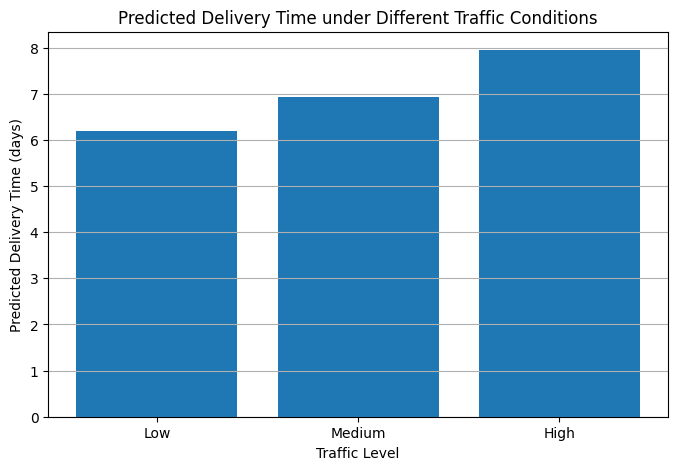

In [27]:
# Visualize traffic scenario comparison

plt.figure(figsize=(8, 5))

plt.bar(
    traffic_comparison["Traffic_Level"],
    traffic_comparison["Predicted_Delivery_Time_Days"]
)

plt.xlabel("Traffic Level")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("Predicted Delivery Time under Different Traffic Conditions")
plt.grid(axis="y")
plt.show()

In [28]:
# Compare weather scenarios for the same shipment

weather_scenarios = []

for weather in ["Clear", "Cloudy", "Rainy", "Stormy"]:

    scenario = shipment.copy()
    scenario["Weather"] = weather

    scenario_df = pd.DataFrame([scenario])

    predicted_days = linear_model.predict(scenario_df)[0]

    weather_scenarios.append({
        "Weather": weather,
        "Predicted_Delivery_Time_Days": predicted_days
    })

weather_comparison = pd.DataFrame(weather_scenarios)

display(weather_comparison.round(2))

,Weather,Predicted_Delivery_Time_Days
0,Clear,6.94
1,Cloudy,7.15
2,Rainy,7.70
3,Stormy,8.51


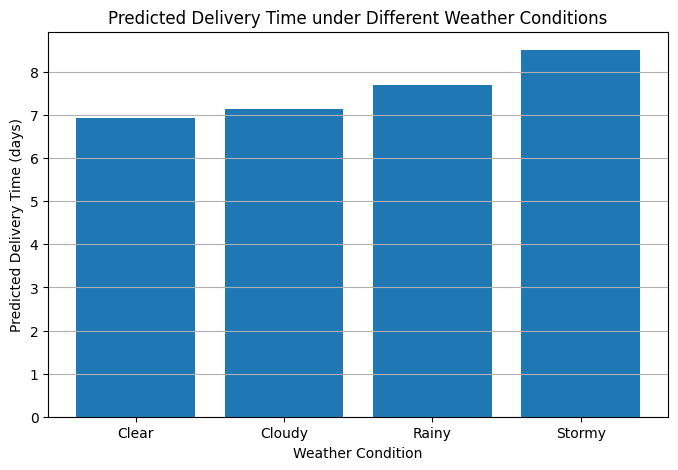

In [29]:
# Visualize weather scenario comparison

plt.figure(figsize=(8, 5))

plt.bar(
    weather_comparison["Weather"],
    weather_comparison["Predicted_Delivery_Time_Days"]
)

plt.xlabel("Weather Condition")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("Predicted Delivery Time under Different Weather Conditions")
plt.grid(axis="y")
plt.show()

### 12.3 Optimization Recommendations

The scenario analysis demonstrates how the predictive model can support logistics planning. For the hypothetical 1,200 km shipment, changes in carrier, traffic, and weather conditions produced measurable differences in predicted delivery time.

The results can be translated into operational strategies such as considering carrier performance alongside cost and capacity, planning routes or dispatch times to reduce exposure to high traffic, and introducing additional delivery-time buffers during adverse weather.

These recommendations are based on model predictions from the simulated dataset. In a real logistics environment, additional factors such as transportation cost, vehicle capacity, route restrictions, service-level agreements, fuel consumption, and real-time traffic data would need to be incorporated before making operational decisions.

In [30]:
# Calculate scenario differences for the optimization analysis

baseline_time = predicted_time

carrier_a_time = carrier_comparison.loc[
    carrier_comparison["Carrier"] == "Carrier A",
    "Predicted_Delivery_Time_Days"
].iloc[0]

carrier_b_time = carrier_comparison.loc[
    carrier_comparison["Carrier"] == "Carrier B",
    "Predicted_Delivery_Time_Days"
].iloc[0]

carrier_c_time = carrier_comparison.loc[
    carrier_comparison["Carrier"] == "Carrier C",
    "Predicted_Delivery_Time_Days"
].iloc[0]

low_traffic_time = traffic_comparison.loc[
    traffic_comparison["Traffic_Level"] == "Low",
    "Predicted_Delivery_Time_Days"
].iloc[0]

high_traffic_time = traffic_comparison.loc[
    traffic_comparison["Traffic_Level"] == "High",
    "Predicted_Delivery_Time_Days"
].iloc[0]

clear_weather_time = weather_comparison.loc[
    weather_comparison["Weather"] == "Clear",
    "Predicted_Delivery_Time_Days"
].iloc[0]

stormy_weather_time = weather_comparison.loc[
    weather_comparison["Weather"] == "Stormy",
    "Predicted_Delivery_Time_Days"
].iloc[0]

print("Optimization Scenario Summary")
print("-----------------------------")

print(f"Baseline predicted delivery time: {baseline_time:.2f} days")

print(
    f"Carrier A vs Carrier B difference: "
    f"{carrier_b_time - carrier_a_time:.2f} days"
)

print(
    f"Carrier A vs Carrier C difference: "
    f"{carrier_c_time - carrier_a_time:.2f} days"
)

print(
    f"Low vs High traffic difference: "
    f"{high_traffic_time - low_traffic_time:.2f} days"
)

print(
    f"Clear vs Stormy weather difference: "
    f"{stormy_weather_time - clear_weather_time:.2f} days"
)

Optimization Scenario Summary
-----------------------------
Baseline predicted delivery time: 6.94 days
Carrier A vs Carrier B difference: 0.65 days
Carrier A vs Carrier C difference: 0.27 days
Low vs High traffic difference: 1.76 days
Clear vs Stormy weather difference: 1.57 days


In [31]:
# Step 13: Operational Optimization
# Compare different carrier, vehicle, and priority combinations

from itertools import product

optimization_data = []

carriers = ["Carrier A", "Carrier B", "Carrier C"]
vehicles = ["Van", "Truck", "Heavy Truck"]
priorities = ["Standard", "Express", "Urgent"]

for carrier, vehicle, priority in product(carriers, vehicles, priorities):

    scenario = pd.DataFrame({
        "Distance_km": [1200],
        "Weight_kg": [500],
        "Traffic_Level": ["Medium"],
        "Weather": ["Clear"],
        "Carrier": [carrier],
        "Vehicle_Type": [vehicle],
        "Warehouse_Processing_Hours": [12],
        "Priority": [priority]
    })

    predicted_time = linear_model.predict(scenario)[0]

    optimization_data.append({
        "Carrier": carrier,
        "Vehicle_Type": vehicle,
        "Priority": priority,
        "Predicted_Delivery_Time_Days": predicted_time
    })

optimization_results = pd.DataFrame(optimization_data)

optimization_results = optimization_results.sort_values(
    "Predicted_Delivery_Time_Days"
).reset_index(drop=True)

display(optimization_results)

,Carrier,Vehicle_Type,Priority,Predicted_Delivery_Time_Days
0,Carrier A,Heavy Truck,Urgent,5.590062
1,Carrier A,Truck,Urgent,5.689840
2,Carrier C,Heavy Truck,Urgent,5.862413
3,Carrier C,Truck,Urgent,5.962192
4,Carrier A,Heavy Truck,Express,6.031375
5,Carrier A,Van,Urgent,6.046575
6,Carrier A,Truck,Express,6.131154
7,Carrier B,Heavy Truck,Urgent,6.237136
8,Carrier C,Heavy Truck,Express,6.303727
9,Carrier C,Van,Urgent,6.318927


In [32]:
# Step 14: Identify the optimal operational configuration

best_option = optimization_results.iloc[0]

print("Optimal Operational Configuration")
print("---------------------------------")
print(f"Carrier: {best_option['Carrier']}")
print(f"Vehicle Type: {best_option['Vehicle_Type']}")
print(f"Priority: {best_option['Priority']}")
print(
    f"Predicted Delivery Time: "
    f"{best_option['Predicted_Delivery_Time_Days']:.2f} days"
)

# Compare with the baseline configuration
baseline_prediction = optimization_results[
    (optimization_results["Carrier"] == "Carrier A") &
    (optimization_results["Vehicle_Type"] == "Truck") &
    (optimization_results["Priority"] == "Standard")
]["Predicted_Delivery_Time_Days"].iloc[0]

optimized_prediction = best_option["Predicted_Delivery_Time_Days"]

improvement = baseline_prediction - optimized_prediction

print(f"\nBaseline Configuration Prediction: {baseline_prediction:.2f} days")
print(f"Optimized Configuration Prediction: {optimized_prediction:.2f} days")
print(f"Predicted Reduction: {improvement:.2f} days")
print(f"Predicted Reduction in Hours: {improvement * 24:.1f} hours")

Optimal Operational Configuration
---------------------------------
Carrier: Carrier A
Vehicle Type: Heavy Truck
Priority: Urgent
Predicted Delivery Time: 5.59 days

Baseline Configuration Prediction: 6.94 days
Optimized Configuration Prediction: 5.59 days
Predicted Reduction: 1.35 days
Predicted Reduction in Hours: 32.4 hours


### 15. Model Selection and Performance Summary

Three regression models were evaluated for predicting logistics delivery time: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

| Model             |   MAE |  RMSE |    R² |
| ----------------- | ----: | ----: | ----: |
| Linear Regression | 0.541 | 0.675 | 0.885 |
| Random Forest     | 0.715 | 0.896 | 0.797 |
| Decision Tree     | 0.941 | 1.185 | 0.645 |

Linear Regression achieved an MAE of **0.541 days**, meaning that the model's average prediction error was approximately **13 hours**. Its RMSE was **0.675 days**, while its R² score of **0.885** indicates that the model explained approximately **88.5% of the variation** in delivery time in the test dataset.

Five-fold cross-validation also supported the model evaluation. Linear Regression achieved a mean cross-validation MAE of **0.553 days** with a standard deviation of **0.025 days**, indicating relatively consistent performance across the validation folds.

Random Forest hyperparameter tuning was performed using GridSearchCV. The selected configuration used **200 estimators, a maximum depth of 12, and a minimum samples split of 2**. The tuned Random Forest achieved a cross-validation MAE of **0.738 days** and a test MAE of **0.715 days**. The tuning process therefore did not improve the test performance compared with the original Random Forest configuration.

Based on the observed results, Linear Regression was selected as the final predictive model because it produced the lowest test MAE and RMSE and the highest R² score among the evaluated models. Its performance was also consistent during five-fold cross-validation.


In [34]:
# Step 15.1: Final Model Performance Summary

final_model_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

display(final_model_summary)

print("\nSelected Final Model: Linear Regression")
print(f"Test MAE: {linear_mae:.3f} days")
print(f"Test RMSE: {linear_rmse:.3f} days")
print(f"Test R²: {linear_r2:.3f}")
print("5-Fold CV MAE: 0.553 days")

,Model,MAE,RMSE,R2
0,Linear Regression,0.540571,0.674914,0.884853
1,Decision Tree,0.940904,1.185059,0.644994
2,Random Forest,0.715440,0.895729,0.797181



Selected Final Model: Linear Regression
Test MAE: 0.541 days
Test RMSE: 0.675 days
Test R²: 0.885
5-Fold CV MAE: 0.553 days


### 17. Conclusion

This project developed a predictive modeling and optimization approach for logistics delivery-time management. A simulated dataset containing 1,500 shipment records was analyzed using Linear Regression, Decision Tree, and Random Forest regression models.

Among the evaluated models, Linear Regression produced the strongest test performance, with an **MAE of 0.541 days**, **RMSE of 0.675 days**, and **R² of 0.885**. Five-fold cross-validation produced a mean MAE of **0.553 days**, supporting the consistency of the model across different validation folds.

The analysis also identified measurable relationships between logistics conditions and predicted delivery time. Distance showed a correlation of **0.744** with delivery time. High traffic was associated with an average delivery time of **8.47 days**, compared with **6.70 days** under low traffic. Stormy weather had an average delivery time of **8.88 days**, compared with **7.22 days** under clear weather.

The optimization analysis evaluated 27 combinations of carrier, vehicle type, and priority for a fixed shipment scenario. The baseline configuration had a predicted delivery time of **6.94 days**, while the lowest predicted configuration used **Carrier A, Heavy Truck, and Urgent priority**, with a predicted delivery time of **5.59 days**. This represents a predicted reduction of **1.35 days or approximately 32.4 hours**.

These results demonstrate how predictive modeling can support logistics planning by estimating delivery times and evaluating alternative operational configurations. In a real logistics environment, the same approach could be extended using historical shipment data and additional information such as transportation cost, vehicle capacity, route constraints, fuel consumption, service-level agreements, and real-time traffic and weather conditions.


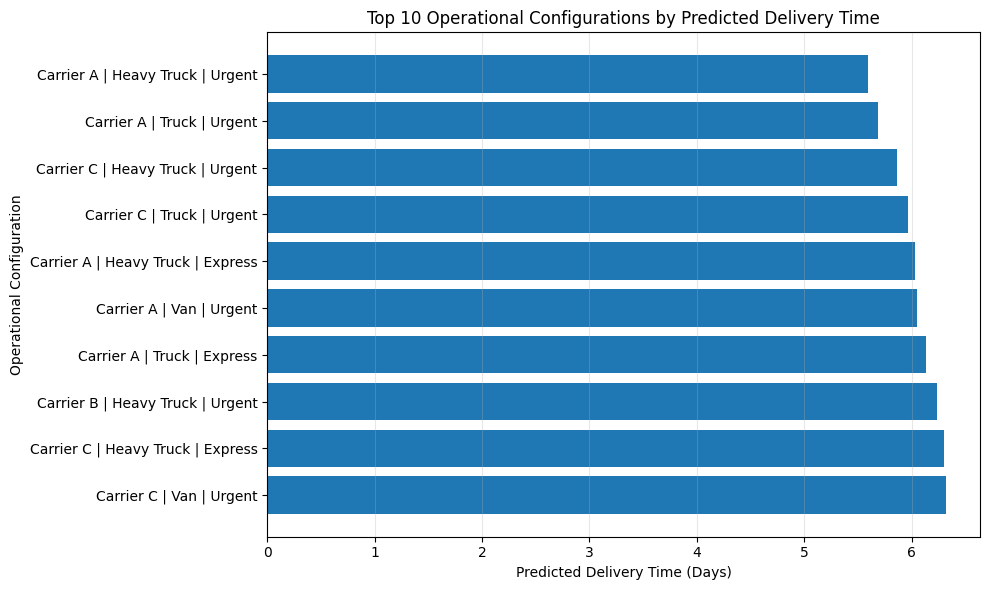

In [35]:
# Step 18: Visualize the top 10 optimized configurations

top_10_optimization = optimization_results.head(10).copy()

top_10_optimization["Configuration"] = (
    top_10_optimization["Carrier"]
    + " | "
    + top_10_optimization["Vehicle_Type"]
    + " | "
    + top_10_optimization["Priority"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_optimization["Configuration"],
    top_10_optimization["Predicted_Delivery_Time_Days"]
)

plt.xlabel("Predicted Delivery Time (Days)")
plt.ylabel("Operational Configuration")
plt.title("Top 10 Operational Configurations by Predicted Delivery Time")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 18.1 Optimization Visualization Interpretation

The optimization chart compares the ten configurations with the lowest predicted delivery times among the 27 tested combinations. The lowest predicted delivery time was obtained using **Carrier A, Heavy Truck, and Urgent priority**, with a predicted delivery time of **5.59 days**.

The baseline configuration of **Carrier A, Truck, and Standard priority** had a predicted delivery time of approximately **6.94 days**. The optimized configuration therefore provides a predicted reduction of **1.35 days**, equivalent to approximately **32.4 hours**.

The visualization demonstrates how predictive modeling can be extended from forecasting to operational scenario analysis. Logistics planners can compare feasible combinations before making decisions. However, the lowest predicted delivery time should not automatically be treated as the final operational choice because real decisions would also need to consider transportation cost, vehicle capacity, availability, customer requirements, and service-level constraints.
